Earthquake Image Dataset Collection and Visual Analysis
A dataset of over 400 earthquake-related images was collected through web scraping using Google Image sources. The dataset includes scenes of building collapse, urban destruction, and rescue operations. All images were cleaned, deduplicated, and processed for further analysis.

In [5]:
!pip install icrawler opencv-python pillow pandas numpy matplotlib seaborn scikit-learn ultralytics


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\24586\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [6]:
import os
import glob
import hashlib
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageOps
from icrawler.builtin import BingImageCrawler
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

os.makedirs("output_photos/images", exist_ok=True)
os.makedirs("output_photos/data", exist_ok=True)
os.makedirs("output_photos/analysis_images", exist_ok=True)
os.makedirs("temp_images", exist_ok=True)

In [7]:
keywords = [
    "earthquake damage building collapse",
    "earthquake disaster rescue",
    "earthquake rubble city",
    "collapsed buildings earthquake"
]

target_per_keyword = 120

for keyword in keywords:
    print("Scraping:", keyword)
    
    crawler = BingImageCrawler(
        downloader_threads=4,
        parser_threads=2,
        storage={"root_dir": f"temp_images/{keyword.replace(' ', '_')}"}
    )
    
    crawler.crawl(
        keyword=keyword,
        max_num=target_per_keyword
    )

print("Scraping finished.")

2026-05-01 18:05:17,859 - INFO - icrawler.crawler - start crawling...
2026-05-01 18:05:17,861 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-01 18:05:17,862 - INFO - icrawler.crawler - starting 2 parser threads...
2026-05-01 18:05:17,864 - INFO - feeder - thread feeder-001 exit
2026-05-01 18:05:17,865 - INFO - icrawler.crawler - starting 4 downloader threads...


Scraping: earthquake damage building collapse


2026-05-01 18:05:19,637 - INFO - parser - parsing result page https://www.bing.com/images/async?q=earthquake damage building collapse&first=20
2026-05-01 18:05:19,683 - INFO - parser - parsing result page https://www.bing.com/images/async?q=earthquake damage building collapse&first=0
2026-05-01 18:05:20,308 - INFO - downloader - image #1	https://c8.alamy.com/comp/R6FJWF/earthquake-damage-fallen-building-staircase-ahmedabad-gujarat-india-R6FJWF.jpg
2026-05-01 18:05:20,323 - INFO - downloader - image #2	https://c8.alamy.com/comp/2CF4CF1/collapsed-building-in-city-after-earthquake-damage-2CF4CF1.jpg
2026-05-01 18:05:20,475 - INFO - downloader - image #3	https://thumbs.dreamstime.com/b/building-collapse-debris-destroyed-building-collapsed-earthquake-catastrophe-ruined-building-rubble-ground-280520185.jpg
2026-05-01 18:05:20,748 - INFO - downloader - image #4	https://thumbs.dreamstime.com/z/building-collapse-structural-damage-gas-explosion-search-rescue-dog-victims-casualty-trapped-rubble-t

Scraping: earthquake disaster rescue


2026-05-01 18:05:48,481 - INFO - parser - parsing result page https://www.bing.com/images/async?q=earthquake disaster rescue&first=20
2026-05-01 18:05:48,517 - INFO - parser - parsing result page https://www.bing.com/images/async?q=earthquake disaster rescue&first=0
2026-05-01 18:05:49,357 - INFO - downloader - image #1	https://static.vecteezy.com/system/resources/thumbnails/029/616/274/small_2x/rescuers-removing-concrete-rubble-neural-network-ai-generated-photo.jpg
2026-05-01 18:05:49,376 - INFO - downloader - image #2	https://static.vecteezy.com/system/resources/thumbnails/029/613/954/small_2x/rescuers-removing-concrete-rubble-neural-network-ai-generated-photo.jpg
2026-05-01 18:05:49,394 - INFO - downloader - image #3	https://static.vecteezy.com/system/resources/thumbnails/031/233/310/small_2x/rescuers-removing-concrete-rubble-neural-network-ai-generated-photo.jpg
2026-05-01 18:05:49,396 - INFO - downloader - image #4	https://static.vecteezy.com/system/resources/thumbnails/031/239/04

Scraping: earthquake rubble city


2026-05-01 18:06:17,448 - INFO - parser - parsing result page https://www.bing.com/images/async?q=earthquake rubble city&first=0
2026-05-01 18:06:17,640 - INFO - parser - parsing result page https://www.bing.com/images/async?q=earthquake rubble city&first=20
2026-05-01 18:06:18,682 - INFO - downloader - image #1	https://thumbs.dreamstime.com/z/rubble-destroyed-city-aftermath-earthquake-rubble-destroyed-city-aftermath-earthquake-created-generative-ai-273992874.jpg
2026-05-01 18:06:18,861 - INFO - downloader - image #2	https://thumbs.dreamstime.com/z/rubble-destroyed-city-aftermath-earthquake-created-generative-ai-rubble-destroyed-city-aftermath-earthquake-273992858.jpg
2026-05-01 18:06:18,893 - INFO - downloader - image #3	https://thumbs.dreamstime.com/z/rubble-destroyed-city-aftermath-earthquake-rubble-destroyed-city-aftermath-earthquake-created-generative-ai-273992893.jpg
2026-05-01 18:06:19,051 - INFO - downloader - image #4	https://thumbs.dreamstime.com/b/earthquake-torn-city-crumbl

Scraping: collapsed buildings earthquake


2026-05-01 18:06:48,814 - INFO - parser - parsing result page https://www.bing.com/images/async?q=collapsed buildings earthquake&first=20
2026-05-01 18:06:48,826 - INFO - parser - parsing result page https://www.bing.com/images/async?q=collapsed buildings earthquake&first=0
2026-05-01 18:06:49,360 - INFO - downloader - image #1	https://c8.alamy.com/comp/2E03E53/buildings-destroyed-after-earthquake-collapsed-wall-in-ruins-2E03E53.jpg
2026-05-01 18:06:50,636 - INFO - downloader - image #2	https://thumbs.dreamstime.com/b/aerial-view-collapsed-buildings-powerful-earthquake-city-366073769.jpg
2026-05-01 18:06:51,013 - INFO - downloader - image #3	https://img.freepik.com/premium-photo/earthquake-showing-damaged-buildings-displaced-debris-amidst-chaos_965119-42526.jpg
2026-05-01 18:06:51,339 - INFO - downloader - image #4	https://img.freepik.com/premium-photo/earthquake-aftermath-collapsed-buildings-rubblestrewn-streets-following-major-earthquakegenerated-with-ai_130181-16887.jpg
2026-05-01 1

Scraping finished.


In [8]:
all_images = glob.glob("temp_images/**/*.*", recursive=True)

count = 0

for path in all_images:
    try:
        img = Image.open(path).convert("RGB")
        save_path = f"output_photos/images/img_{count:04d}.jpg"
        img.save(save_path, quality=95)
        count += 1
    except:
        pass

print("Merged:", count)

Merged: 269


In [9]:
image_paths = glob.glob("output_photos/images/*.jpg")

valid_paths = []
hashes = set()

for path in image_paths:
    try:
        img = Image.open(path).convert("RGB")
        img = ImageOps.exif_transpose(img)

        small = img.resize((64, 64))
        h = hashlib.md5(small.tobytes()).hexdigest()

        if h not in hashes:
            hashes.add(h)
            valid_paths.append(path)
        else:
            os.remove(path)

    except:
        os.remove(path)

print("Valid images:", len(valid_paths))

Valid images: 240


In [10]:
image_paths = sorted(glob.glob("output_photos/images/*.jpg"))

if len(image_paths) > 400:
    for p in image_paths[400:]:
        os.remove(p)

image_paths = sorted(glob.glob("output_photos/images/*.jpg"))

print("Final count:", len(image_paths))

Final count: 240


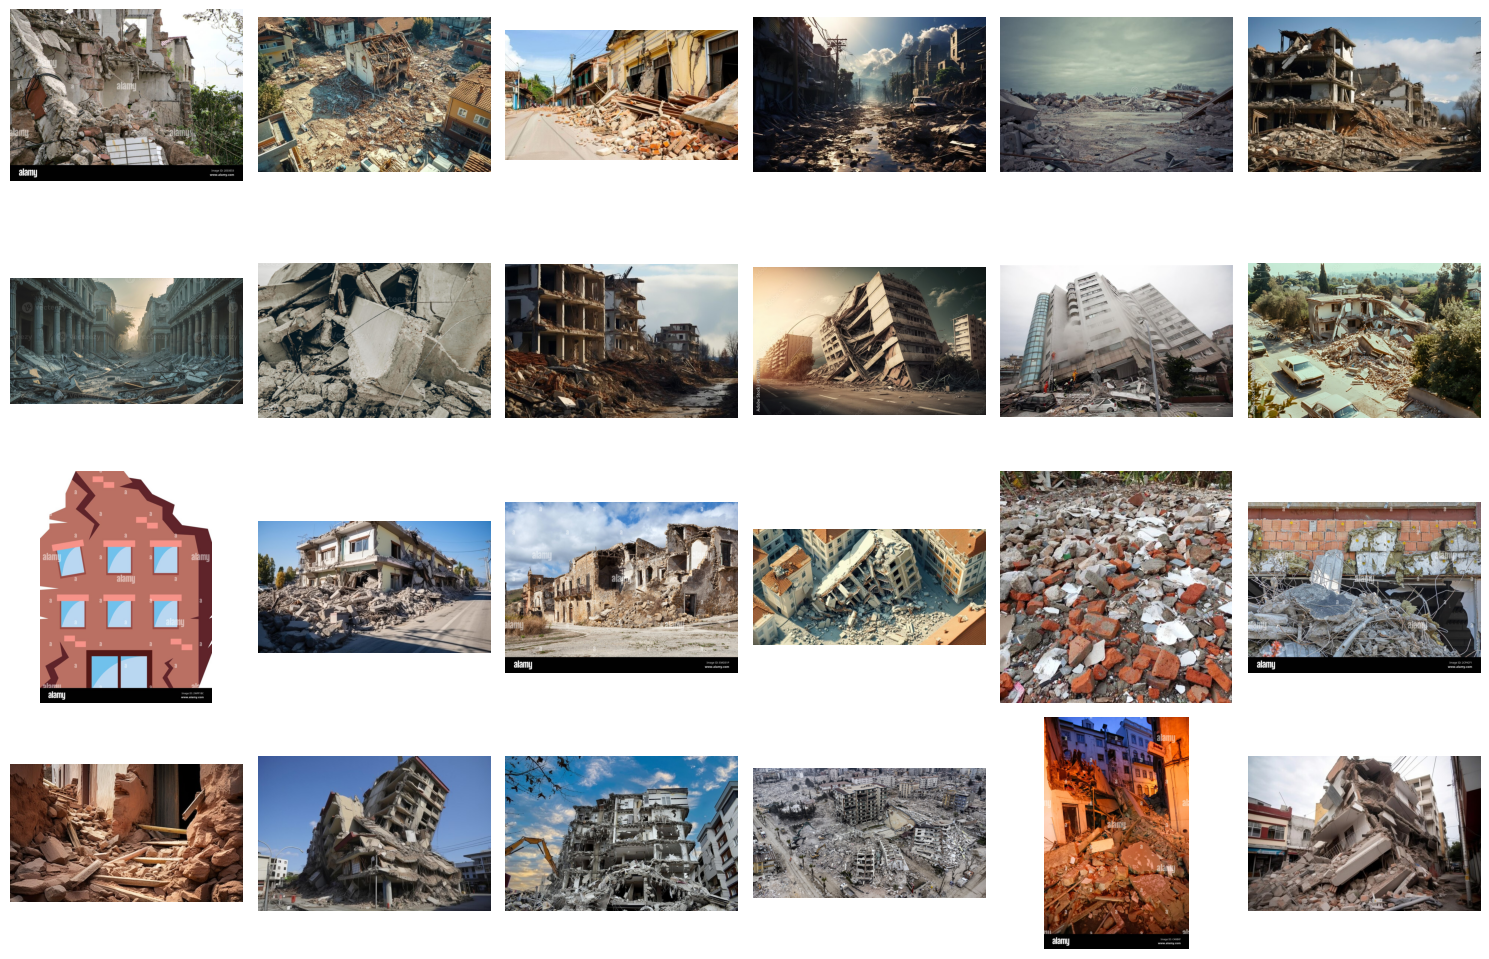

In [11]:
sample = image_paths[:24]

fig, axes = plt.subplots(4, 6, figsize=(15,10))

for ax, path in zip(axes.flatten(), sample):
    img = Image.open(path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.savefig("output_photos/sample_grid.png", dpi=300)
plt.show()

In [12]:
records = []

for path in image_paths:
    img = cv2.imread(path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray)
    contrast = np.std(gray)

    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    records.append({
        "image_path": path,
        "brightness": brightness,
        "contrast": contrast,
        "edge_density": edge_density
    })

df_img = pd.DataFrame(records)

In [13]:
df_img["darkness"] = 255 - df_img["brightness"]

df_img["damage_proxy"] = (
    df_img["edge_density"] * 0.5 +
    (df_img["contrast"]/df_img["contrast"].max()) * 0.3 +
    (df_img["darkness"]/df_img["darkness"].max()) * 0.2
)

In [14]:
features = df_img[["brightness","contrast","edge_density","damage_proxy"]]

scaler = StandardScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
df_img["cluster"] = kmeans.fit_predict(X)

In [15]:
# brightness
plt.figure()
sns.histplot(df_img["brightness"], bins=30)
plt.title("Brightness Distribution")
plt.savefig("output_photos/analysis_images/brightness.png", dpi=300)
plt.close()

# edge
plt.figure()
sns.histplot(df_img["edge_density"], bins=30)
plt.title("Edge Density")
plt.savefig("output_photos/analysis_images/edge.png", dpi=300)
plt.close()

# damage
plt.figure()
sns.histplot(df_img["damage_proxy"], bins=30)
plt.title("Damage Proxy")
plt.savefig("output_photos/analysis_images/damage.png", dpi=300)
plt.close()

# cluster
plt.figure()
sns.countplot(x=df_img["cluster"])
plt.title("Cluster Distribution")
plt.savefig("output_photos/analysis_images/cluster.png", dpi=300)
plt.close()

2026-05-01 18:07:22,273 - INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-01 18:07:22,277 - INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_img["cluster"])
plt.title("PCA Clusters")
plt.savefig("output_photos/analysis_images/pca.png", dpi=300)
plt.close()

In [17]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

yolo_data = []

for i, path in enumerate(image_paths):
    print(i)

    results = model(path, verbose=False)

    obj_count = 0
    person_count = 0

    for r in results:
        for box in r.boxes:
            obj_count += 1
            cls_id = int(box.cls[0])
            if model.names[cls_id] == "person":
                person_count += 1

    yolo_data.append({
        "image_path": path,
        "person_count": person_count,
        "total_objects": obj_count
    })

df_yolo = pd.DataFrame(yolo_data)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239


In [18]:
df_final = df_img.merge(df_yolo, on="image_path")

df_final.to_csv("output_photos/data/full_analysis.csv", index=False)

In [19]:
plt.figure()
sns.histplot(df_final["person_count"])
plt.title("People Count")
plt.savefig("output_photos/analysis_images/yolo_people.png", dpi=300)
plt.close()

plt.figure()
sns.histplot(df_final["total_objects"])
plt.title("Object Count")
plt.savefig("output_photos/analysis_images/yolo_objects.png", dpi=300)
plt.close()

In [20]:
df_blender = df_final[[
    "brightness",
    "contrast",
    "edge_density",
    "damage_proxy",
    "cluster",
    "person_count",
    "total_objects"
]]

df_blender.to_csv("output_photos/data/blender_input.csv", index=False)